## Imports

In [14]:
from datetime import datetime, time
import pandas as pd
import numpy as np
from itertools import product
from Strategies.Modular_strategy.calibration import ModularStrategyCalibration
from Strategies.Modular_strategy.backtest_class import BacktestModular
from Strategies.Modular_strategy.strategy_class_no_trailing import ModularStrategy as Strategy
from Strategies.Modular_strategy.strategy_class_new import ModularStrategy as NewStrategy
from Strategies.Modular_strategy.configurable_modular_strategy import * # or StandardClosingLogic

from Strategies.Sparse_momentum.ob_attributes import OB_attributes, TR_attributes


import pickle
from Strategies.Modular_strategy.features import *
from Strategies.Sparse_momentum.ob_attributes import OB_attributes
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Database.TPData import TPData, TPDataDa
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import date_filter
from Utilities.Storage import get_curr_storage_path

In [4]:
def clean_ba_dupl(df_input):
    df = df_input[['b_price', 'a_price', 'trd_price']].copy()
    df['b_price_lag'] = df['b_price'].shift(1)
    df['a_price_lag'] = df['a_price'].shift(1)
    df['mask'] = (
        (df['b_price_lag'] != df['b_price']) |
        (df['a_price_lag'] != df['a_price']) |
        (~df['trd_price'].isna())
    )
    return df['mask']


In [5]:
def from_key_to_params(params, fixed_params, features_pool):
    if isinstance(params, str):
        params = params.split('_')

    ptr = 0
    result = {}
    
    for feature_name, feature_class in features_pool.items():        
        # Now call get_t() on the instance
        threshold_count = len(feature_class.get_t())
        suffix = feature_name.split("_")[-1] if 'sfx' in feature_name else ""
        feature_config = {'active': True}
        
        if threshold_count > 0:
            feature_params = params[ptr:ptr+threshold_count]
            ptr += threshold_count
            feature_config['params'] = {
                f'thold_{i+1}': param 
                for i, param in enumerate(feature_params)
            }
        feature_config['suffix'] = suffix

        result[feature_name] = feature_config
    
    return {**result, **fixed_params}

LOAD yesterday data

## Pickle load

In [6]:
_STORAGE = get_curr_storage_path()
# df_data = pd.read_parquet(_STORAGE + DIR_PATH + f'backtest_obt_{_INSTRUMENT}.parquet')
df_data = pd.read_parquet(_STORAGE + 'data_factory/' + f'backtest_obt_dem1.parquet')
df_data = df_data[~df_data['b_price'].isna()]
df_data = df_data[clean_ba_dupl(df_data)]
df_data = df_data.reset_index(names='timestamp')
df_data['ba_spread'] = (df_data['a_price'] - df_data['b_price']).round(2)
df_data.loc[df_data['trd_price'] > 0, 'trd_vol'] = 1
day = datetime(2025, 1, 24).date()
df_data = df_data[df_data['timestamp'].dt.date != day]

df_data.reset_index(inplace=True, drop=True)
df_data.reset_index(names='index', inplace=True)
df = df_data

In [5]:
df = df[df['timestamp'].dt.date > datetime(2025,4,1).date()]

In [7]:
df

,index,timestamp,b_price,a_price,b_vol,a_vol,mid_price,b_price_sparsity,a_price_sparsity,trd_side,last_trade_margin,trd_gap,trd_price,bid_t1,ask_t1,ba_spread,trd_vol
0,0,2025-04-04 08:59:58.288000000,64.31,64.55,2.0,1.0,64.430,0.07,0.06,NaN,NaN,NaN,NaN,True,True,0.24,NaN
1,1,2025-04-04 09:00:18.067000000,64.31,64.54,2.0,1.0,64.425,0.07,0.07,NaN,NaN,NaN,NaN,True,True,0.23,NaN
2,2,2025-04-04 09:00:18.156000000,64.31,64.55,2.0,1.0,64.430,0.07,0.14,NaN,NaN,NaN,NaN,True,True,0.24,NaN
3,3,2025-04-04 09:00:39.171000000,64.31,64.54,3.0,1.0,64.425,0.07,0.09,NaN,NaN,NaN,NaN,True,True,0.23,NaN
4,4,2025-04-04 09:00:45.955000000,64.33,64.54,2.0,1.0,64.435,0.03,0.09,NaN,NaN,NaN,NaN,True,False,0.21,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1230080,1230080,2025-06-23 17:58:38.164275759,82.81,82.90,2.0,1.0,82.855,0.10,0.08,0.0,0.0,0.0,82.81,True,True,0.09,1.0
1230081,1230081,2025-06-23 17:58:38.671876139,82.81,82.90,2.0,1.0,82.855,0.10,0.08,0.0,0.0,0.0,82.81,True,True,0.09,1.0
1230082,1230082,2025-06-23 17:58:38.877318573,82.81,82.90,2.0,1.0,82.855,0.10,0.08,0.0,0.0,0.0,82.81,True,True,0.09,1.0
1230083,1230083,2025-06-23 17:58:39.538018290,82.81,82.90,2.0,1.0,82.855,0.10,0.08,0.0,0.0,0.0,82.81,True,True,0.09,1.0


## Strategy run

In [12]:
    # best params [0.4, 0.19, 0.08, 0.51, 1.0]
    # best closing ['0.75', '0.4', '0.1', '30']
backtest_class = BacktestModular()
# params
fixed_params = {
    'make_profit_margin': 0.25,
    'stop_loss': 0.3,
    'stop_profit': 0.1,
    'burnout_period': 5,
    'makeagg_ratio': 0.6,
    'br_fee': 0.04 / 2,
    't_end': time(17, 00),
    'hard_sl': 1.0,
    'closing_mode': 'Other',
    'close_trade_info': None
}
strategy_columns = df_data.columns.values

features_pool = {
    'feature_sparsity': FeatureSparsity,
    'feature_trd_gap': FeatureTradedAboveBO,
    'feature_ba_spread': FeatureBASpread,
    'feature_order_t1': FeatureOrderT1
}

params = {
    'feature_sparsity': {'active': True, 'params': {'thold_dense': 0.25, 'thold_sparse': 0.12}, 'suffix': ""},
    'feature_trd_gap': {'active': True, 'params': {'thold': 0.04}, 'suffix': ""},
    'feature_ba_spread': {'active': True, 'params': {'thold': 0.21}, 'suffix': ""},
    # 'feature_trd_gap_counter': {'active': True, 'params': {'thold': 2}, 'suffix': ""},
    'feature_order_t1': {'active': True, 'suffix': ""}
}

Best combination: [0.26, 0.09, 0.46, -1.1, 1.1, 0.79, 0.24, 1.0]

In [9]:
data_columns = ['a_price_sparsity',
'b_price_sparsity',
'trd_gap',
'bid_t1',
'ask_t1',
'ba_spread']
indices = df[df[data_columns].notnull().all(axis=1)].index.tolist()


In [15]:
# params = from_key_to_params([0.65, 0.06, 0.82, -0.01, 0.0, 2.0, -1.1, -0.5, 0.4, 1.0], fixed_params, features_pool)

strategy = Strategy(features_pool, 
                    strategy_columns, 
                    {**params, **fixed_params}, 
                    max_position=1)
backtest_class.simulate_strategy(strategy, df, indices, cached_returns=None)
xx = backtest_class.calc_returns_new(strategy)

In [16]:
xx

,timestamp,position,action,open_price,price_level,returns
0,2025-04-04 09:03:25.328082125,1.0,1.0,64.70,64.70,0.00
1,2025-04-04 09:08:57.982860734,0.0,-1.0,64.70,64.84,0.14
2,2025-04-04 09:52:06.554931728,1.0,1.0,64.40,64.40,NaN
3,2025-04-04 09:55:26.319000000,0.0,-1.0,64.40,64.65,0.25
4,2025-04-04 09:55:34.664215545,-1.0,-1.0,64.64,64.64,NaN
...,...,...,...,...,...,...
1923,2025-06-23 16:27:56.714832430,0.0,-1.0,83.07,82.88,-0.19
1924,2025-06-23 16:51:50.324119249,-1.0,-1.0,82.95,82.95,NaN
1925,2025-06-23 16:53:16.733376603,0.0,1.0,82.95,82.75,0.20
1926,2025-06-23 16:54:50.249524747,-1.0,-1.0,82.48,82.48,NaN


<Axes: >

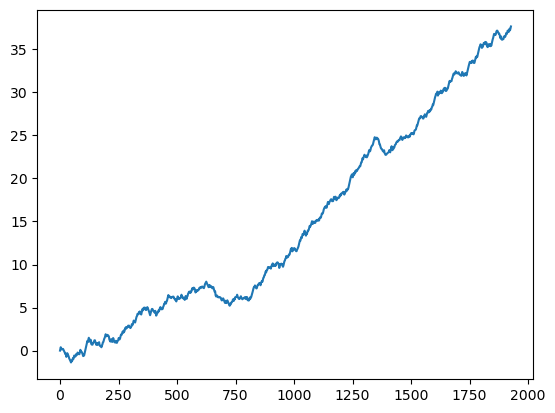

In [17]:
xx['returns'].dropna().cumsum().plot()

In [ ]:
# One-liner version
mask = df_data['obook_a_price_sparsity_dem2_rolling_50'] > 0.1
# mask &= df_data['obook_a_price_sparsity_dem2'] > 0.2
# mask &= df_data['obook_ba_volrat_50_dem2'] > 0.4

print('shape', mask.sum())
print('Base\n', df_data['multiclass_label'].value_counts()/df_data.shape[0], '\n*****************')
df_data[mask]['multiclass_label'].value_counts()/df_data[mask].shape[0]



shape 610
Base
 multiclass_label
1    0.874777
2    0.072369
0    0.052854
Name: count, dtype: float64 
*****************


multiclass_label
1    0.847541
2    0.108197
0    0.044262
Name: count, dtype: float64

In [ ]:
# One-liner version
mask = df_data['obook_a_price_sparsity_dem2_rolling_50'] > 0.1
# mask &= df_data['obook_a_price_sparsity_dem2'] > 0.2
# mask &= df_data['obook_ba_volrat_50_dem2'] > 0.4

print('shape', mask.sum())
print('Base\n', df_data['multiclass_label'].value_counts()/df_data.shape[0], '\n*****************')
df_data[mask]['multiclass_label'].value_counts()/df_data[mask].shape[0]



shape 610
Base
 multiclass_label
1    0.874777
2    0.072369
0    0.052854
Name: count, dtype: float64 
*****************


multiclass_label
1    0.847541
2    0.108197
0    0.044262
Name: count, dtype: float64

In [ ]:
# One-liner version
mask = df_data['obook_a_price_sparsity_dem2_rolling_50'] > 0.1
# mask &= df_data['obook_a_price_sparsity_dem2'] > 0.2
# mask &= df_data['obook_ba_volrat_50_dem2'] > 0.4

print('shape', mask.sum())
print('Base\n', df_data['multiclass_label'].value_counts()/df_data.shape[0], '\n*****************')
df_data[mask]['multiclass_label'].value_counts()/df_data[mask].shape[0]



shape 610
Base
 multiclass_label
1    0.874777
2    0.072369
0    0.052854
Name: count, dtype: float64 
*****************


multiclass_label
1    0.847541
2    0.108197
0    0.044262
Name: count, dtype: float64

In [ ]:
# One-liner version
mask = df_data['obook_a_price_sparsity_dem2_rolling_50'] > 0.1
# mask &= df_data['obook_a_price_sparsity_dem2'] > 0.2
# mask &= df_data['obook_ba_volrat_50_dem2'] > 0.4

print('shape', mask.sum())
print('Base\n', df_data['multiclass_label'].value_counts()/df_data.shape[0], '\n*****************')
df_data[mask]['multiclass_label'].value_counts()/df_data[mask].shape[0]



shape 610
Base
 multiclass_label
1    0.874777
2    0.072369
0    0.052854
Name: count, dtype: float64 
*****************


multiclass_label
1    0.847541
2    0.108197
0    0.044262
Name: count, dtype: float64

In [13]:
xx

,timestamp,position,action,open_price,price_level,returns
0,2025-04-02 09:22:17.679795536,-1,-1,88.05,88.05,0.0
1,2025-04-02 09:29:25.223691375,0,1,88.10,88.10,0.0
2,2025-04-02 12:28:12.677662924,1,1,86.40,86.40,NaN
3,2025-04-02 12:28:32.283000000,0,-1,86.25,86.25,0.0
4,2025-04-04 11:10:56.270941327,-1,-1,79.70,79.70,NaN
5,2025-04-04 11:28:13.167584988,0,1,79.90,79.90,0.0
6,2025-04-08 13:34:36.576785021,1,1,60.15,60.15,NaN
7,2025-04-08 13:35:14.929000000,0,-1,60.35,60.35,0.0
8,2025-04-10 14:30:12.210477332,1,1,67.70,67.70,NaN
9,2025-04-10 14:36:34.171212607,0,-1,67.50,67.50,0.0


In [216]:
from Database.DB_reader import Database
_START_DATE = '2025-05-19'
db = Database()
stmt = f"""
SELECT st.* FROM algo.strategy_trades AS st
WHERE algo_id = 'spb-fr-m-2'
AND execution_time > '{_START_DATE}'
ORDER BY st.execution_time;
"""
trades = db.execute_general_query(stmt)[['execution_time', 'buy_delivery_area', 'price']]
trades

Connected to the database postgre
Disconnected from the database postgre


,execution_time,buy_delivery_area,price
0,2025-05-19T13:16:53.034000,,29.22
1,2025-05-19T13:17:09.787000,10001075,29.01
2,2025-05-19T13:50:30.875000,10001075,29.35
3,2025-05-19T13:53:55.496000,,29.60
4,2025-05-20T12:49:39.662000,,35.70
5,2025-05-20T13:10:21.919000,10001075,35.63
6,2025-05-21T07:24:33.102000,,38.50
7,2025-05-21T07:24:33.312000,10001075,38.25
8,2025-05-21T12:00:07.755000,,39.31
9,2025-05-21T12:08:46.264000,10001075,39.35


In [217]:
def convert_to_target_timezone(ts, target_tz='Europe/Berlin'):
    dt = pd.to_datetime(ts)
    if dt.tzinfo is None:
        # Localize naive timestamps to target timezone
        dt = dt.tz_localize(target_tz)
    else:
        # Convert aware timestamps to target timezone
        dt = dt.tz_convert(target_tz)
    return dt

# Apply the conversion to the entire execution_time Series
trades['timestamp'] = trades['execution_time'].apply(convert_to_target_timezone)

# Manually adjust the timestamp for the problematic entry if needed
# Assuming index 5 is the manually inserted trade (2025-05-05 14:05:56+02:00)
# If the time itself is incorrect, override it with the intended time
# manual_index = 0  # Adjust based on your data if different
# intended_time = '2025-05-05 12:05:56'  # Adjust to the correct intended time if needed
# trades.loc[manual_index, 'timestamp'] = pd.to_datetime(intended_time).tz_localize('Europe/Berlin')

# Sort by timestamp and reset index
trades = trades.sort_values(by='timestamp')
trades.reset_index(drop=True, inplace=True)

# Rest of the code remains unchanged
condition = pd.to_numeric(trades['buy_delivery_area']) > 0
trades['action'] = 1  # Default value
trades['action'] = trades['action'].where(condition, -1)
# Create open_flag as a boolean mask
trades['open_flag'] = trades.index % 2 == 0

# Use the boolean mask to get prices for open positions
trades['open_price'] = trades.loc[trades['open_flag'], 'price']

# Forward fill the open_price values
trades['open_price'] = trades['open_price'].ffill()

# Initialize position column with zeros
trades['position'] = 0

# Define your condition (though it's not used in the final line)
condition = (trades['price'] - trades['open_price']).abs() > 0.001

# Update position where open_flag is True with the action value
trades['position'] = trades['position'].mask(trades['open_flag'], trades['action'])

df_temp = trades[['timestamp', 'position', 'action', 'price', 'open_price']]
last_position = None
returns = []
is_closing = lambda x, y: abs(y) < abs(x)

for row in df_temp.to_dict(orient='records'):
    if last_position is None:
        # For the first row, include it but set return as 0 since it's opening a position
        r = np.nan
        returns.append({'timestamp': row['timestamp'],
                        'position': row['position'],
                        'action': row['action'],
                        'open_price': row['open_price'],
                        'price': row['price'],
                        'returns': r*abs(row['action'])})
        last_position = row['position']
        continue
        
    if is_closing(last_position, row['position']):
        if row['action'] > 0:
            # closing short
            r = row['open_price'] - row['price']
        else:
            # closing long
            r = row['price'] - row['open_price']
    else:
        r = np.nan
        
    returns.append({'timestamp': row['timestamp'],
                    'position': row['position'],
                    'action': row['action'],
                    'open_price': row['open_price'],
                    'price': row['price'],
                    'returns': r*abs(row['action'])})
    
    # Update last_position for the next iteration
    last_position = row['position']
    
result = pd.DataFrame(returns)


In [11]:
result['returns'].mean()

NameError: name 'result' is not defined

In [220]:
result['returns'].dropna().astype(float).sum() - result['returns'].astype(float).dropna().shape[0]*0.04

0.51

In [218]:
result['returns']

0       NaN
1      0.21
2       NaN
3      0.25
4       NaN
5      0.07
6       NaN
7      0.25
8       NaN
9     -0.04
10      NaN
11     0.01
12      NaN
Name: returns, dtype: object

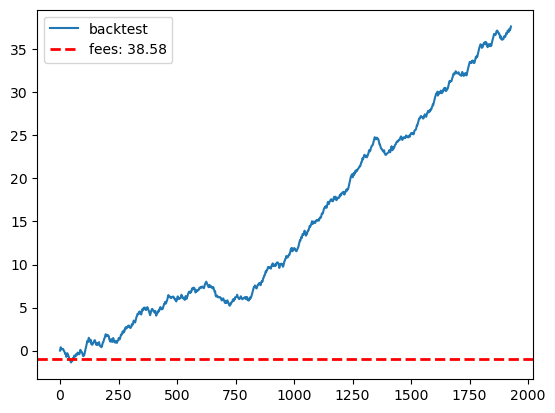

In [18]:
import matplotlib.pyplot as plt

fees = (abs(xx.iloc[0]['position']) + abs(xx['action']).sum())*fixed_params['br_fee']
plt.plot(xx['returns'].dropna().cumsum(), label='backtest')
# plt.plot(result['returns'].dropna().cumsum(), label='prod')
plt.axhline(xx['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()

# Show plot
plt.show()

In [ ]:
returns = xx[~pd.isna(xx['returns'])]

In [ ]:
pd.DataFrame(strategy.daily_profit).hist()

In [ ]:
returns['dupl'] = returns.duplicated(subset='date')

In [19]:
xx['returns'].sum()-fees

-0.9299999999999358

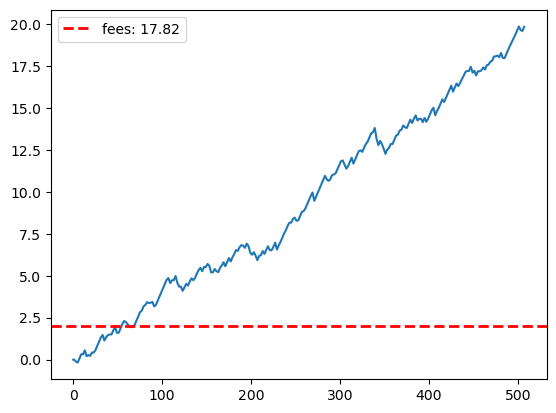

In [91]:
import matplotlib.pyplot as plt

fees = (abs(xx.iloc[0]['position']) + abs(xx['action']).sum())*fixed_params['br_fee']
plt.plot(xx['returns'].dropna().cumsum())
plt.axhline(xx['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()

# Show plot
plt.show()

In [ ]:
one_day_returns = {
    'date': [],
    'returns': []
}
dates = xx['timestamp'].dt.date.unique()
for i, date in enumerate(dates):
    one_day_returns['date'].append(date)
    one_day_returns['returns'].append(xx[xx['timestamp'].dt.date == date]['returns'].sum())

three_day_returns = {
    'date': [],
    'returns': []
}
dates = xx['timestamp'].dt.date.unique()
i = 0
temp_ret = 0
for date in dates:
    if i%3==0:
        three_day_returns['date'].append(date)
        temp_ret += xx[xx['timestamp'].dt.date == date]['returns'].sum()
        three_day_returns['returns'].append(temp_ret)
        i += 1
        temp_ret = 0
    else:
        temp_ret += xx[xx['timestamp'].dt.date == date]['returns'].sum()
        i += 1

returns_dist = pd.DataFrame(one_day_returns)['returns']
import arviz as az
az.rcParams["stats.ci_prob"] = 0.93

plt.figure()
plt.title("one day returns high density 93% interval")
plt.scatter(x=returns_dist.values, y=np.ones(len(returns_dist.values)), alpha=0.5)
hdi = az.hdi(np.array(returns_dist.values))
plt.axvline(hdi[0], linestyle="--", linewidth=2)
plt.axvline(hdi[1], linestyle="--", linewidth=2)
plt.axvline(np.mean(returns_dist.values), linestyle="-.", color="black")
# plt.xlim(left=0.0, right=1.0)
plt.show()
print('min: ', np.min(returns_dist.values))
print('max: ', np.max(returns_dist.values))

returns_dist = pd.DataFrame(three_day_returns)['returns']
plt.figure()
plt.title("three days returns high density 93% interval")
plt.scatter(x=returns_dist.values, y=np.ones(len(returns_dist.values)), alpha=0.5)
hdi = az.hdi(np.array(returns_dist.values))
plt.axvline(hdi[0], linestyle="--", linewidth=2)
plt.axvline(hdi[1], linestyle="--", linewidth=2)
plt.axvline(np.mean(returns_dist.values), linestyle="-.", color="black")
# plt.xlim(left=0.0, right=1.0)
plt.show()
print('min: ', np.min(returns_dist.values))
print('max: ', np.max(returns_dist.values))


In [ ]:
returns_dist = pd.DataFrame(three_day_returns)['returns']

In [ ]:
import arviz as az
az.rcParams["stats.ci_prob"] = 0.93

plt.figure()
plt.title("returns high density 93% interval")
plt.scatter(x=returns_dist.values, y=np.ones(len(returns_dist.values)), alpha=0.5)
hdi = az.hdi(np.array(returns_dist.values))
plt.axvline(hdi[0], linestyle="--", linewidth=2)
plt.axvline(hdi[1], linestyle="--", linewidth=2)
plt.axvline(np.mean(returns_dist.values), linestyle="-.", color="black")
# plt.xlim(left=0.0, right=1.0)
plt.show()
print('min: ', np.min(returns_dist.values))
print('max: ', np.max(returns_dist.values))

In [ ]:
# OPEN/CLOSE data entries
df_stats = pd.DataFrame(strategy.stats_dict)
df_stats

In [ ]:
xx.to_clipboard()

### Create dataframe for timestamps of interest

In [ ]:
# Create an empty list to store the results
filtered_data = []

# Iterate through each row in df_stats
for index, row in df_stats.iterrows():
    # Define the time window
    start_time = row['timestamp'] - pd.Timedelta(minutes=1)
    end_time = row['timestamp'] + pd.Timedelta(minutes=1)
    
    # Filter df_data within the time window
    condition = (df_data['timestamp'] >= start_time) & (df_data['timestamp'] <= end_time)
    matching_data = df_data[condition]
    
    # Append the matching data to the list
    filtered_data.append(matching_data)

# Concatenate all the filtered dataframes into a single dataframe
position_data = pd.concat(filtered_data).reset_index(drop=True)

In [ ]:
import matplotlib.pyplot as plt

fees = (abs(xx.iloc[0]['position']) + abs(xx['action']).sum())*fixed_params['br_fee']
plt.plot(xx['returns'].dropna().cumsum())
plt.axhline(xx['returns'].sum()-fees, color='r', linestyle='dashed', linewidth=2, label=f'fees: {fees:.2f}')
# Add a legend
plt.legend()

# Show plot
plt.show()

In [ ]:
bb = df_data.set_index('timestamp').reindex(xx[xx['position'] != 0]['timestamp'])

In [ ]:
pd.DataFrame(strategy.stats_dict).to_clipboard()

## Compare prod/backtest

In [ ]:
[[pd.to_datetime(x['timestamp'], unit='s', utc=True).tz_convert('Europe/Berlin'), x['price'], x['direction']] for x in a]

In [ ]:
pd.Series([xx.sample(len(xx)-3)['returns'].sum() for _ in range(100)]).hist()

## RETURNS HISTOGRAM

Accuracy: 0.5529045643153527


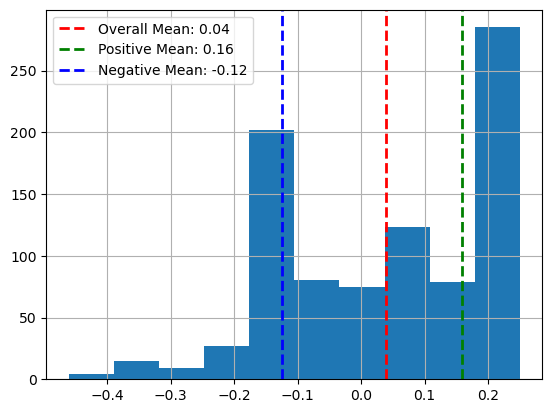

<Axes: >

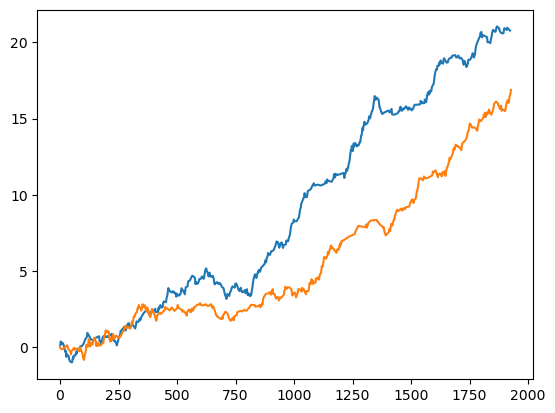

In [20]:
import matplotlib.pyplot as plt

# Assuming 'xx' is a DataFrame and 'returns' is a column in it
overall_mean = xx['returns'].mean()
positive_mean = xx[xx['returns'] > 0]['returns'].mean()
negative_mean = xx[xx['returns'] < 0]['returns'].mean()

# Print accuracy
accuracy = sum(xx['returns'] > 0) / (len(xx)/2)
print('Accuracy:', accuracy)

# Plot histogram
xx[abs(xx['returns']) >= 0.01]['returns'].hist()

# Add vertical lines
plt.axvline(overall_mean, color='r', linestyle='dashed', linewidth=2, label=f'Overall Mean: {overall_mean:.2f}')
plt.axvline(positive_mean, color='g', linestyle='dashed', linewidth=2, label=f'Positive Mean: {positive_mean:.2f}')
plt.axvline(negative_mean, color='b', linestyle='dashed', linewidth=2, label=f'Negative Mean: {negative_mean:.2f}')

# Add a legend
plt.legend()

# Show plot
plt.show()

xx[xx['action'] == -1]['returns'].dropna().cumsum().plot(label='short')
xx[xx['action'] == 1]['returns'].dropna().cumsum().plot()



# Bernoulli simulations

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

# Parameters
profit = 0.24
loss = 0.23
n = 1000
p = 0.6
trades = 200

# Simulate trades and calculate returns
returns = np.array([
    np.cumsum(np.where(bernoulli.rvs(p=p, size=trades), profit, -loss))
    for _ in range(n)
])

# Calculate percentiles
percentiles = np.array([
    [
        np.percentile(returns[:, i], 3),
        np.percentile(returns[:, i], 5),
        np.percentile(returns[:, i], 10),
        np.percentile(returns[:, i], 50)
    ]
    for i in range(returns.shape[1])
])

# Extract percentiles for plotting
x = np.arange(trades)
p3, p5, p10, p50 = percentiles.T

# Plot
plt.figure(figsize=(12, 6))

# Plot all simulation lines with low opacity
for simulation in returns:
    plt.plot(x, simulation, color='gray', alpha=0.02)

# Overlay percentiles
plt.plot(x, p3, color='blue', label='3rd Percentile')
plt.plot(x, p5, color='green', label='5th Percentile')
plt.plot(x, p10, color='purple', label='10th Percentile')
plt.plot(x, p50, color='red', label='Median (50th Percentile)', linewidth=2)
plt.axhline(y=np.min(p10), label=f'p3 minimum ({np.min(p10)})', color='k', linewidth=2, linestyle='--')

plt.xlabel('Trades')
plt.ylabel('Cumulative Returns')
plt.title('Simulation with Percentiles for Cumulative Returns')
plt.legend()
plt.grid()
plt.show()


In [ ]:
returns[:,10]

In [ ]:
df_data.columns

In [ ]:
def from_key_to_params(string, fixed_params):
    params = list(map(float, string.split('_')))
    return {
        'feature_order_t1': {'active': True},
        'feature_traded_abo': {'active': True, 'params': {'thold_margin': params[0]}},
        'feature_ba_break': {'active': True, 'params': {'thold_bas': params[1], 'thold_min_bas': params[2]}},
        'take_profit': params[3],
        'stop_profit': params[5],
        'stop_loss': params[4],
        'burnout_period': params[6],
        'makeagg_ratio': params[7],
        **fixed_params
    }

In [ ]:
params = from_key_to_params('0.23_0.4_0.0_0.5_0.5_0.1_30_0.6', fixed_params)
params

In [ ]:
strategy = ModularStrategy(features_pool, strategy_columns, {**params})
backtest_class.simulate_strategy(strategy, df_data)
xx = backtest_class.calc_returns(strategy)

In [ ]:
xx = backtest_class.calc_returns(strategy)
xx.sample(13['returns'].cumsum().plot()

In [ ]:
xx.sample(14).reset_index()['returns'].cumsum().plot()

In [ ]:
xx = backtest_class.calc_returns(strategy)
xx['returns'].cumsum().plot()

In [ ]:
def convert_to_target_timezone(ts, target_tz='Europe/Berlin'):
    dt = pd.to_datetime(ts)
    if dt.tzinfo is None:
        # Localize naive datetime to target timezone
        dt = dt.tz_localize(target_tz)
    else:
        # Convert aware datetime to target timezone
        dt = dt.tz_convert(target_tz)
    return dt

# Apply the conversion to the entire Series
trades['timestamp'] = trades['execution_time'].apply(convert_to_target_timezone)


In [ ]:
trades

# Trades inspecting

In [ ]:
import plotly.graph_objects as go
from Utilities.dfutils import show_in_window

trades_backtest = pd.DataFrame(strategy.stats_dict)

df_ob = df_data.copy().dropna(subset=['trd_price'])
fig = go.Figure()
fig.add_trace(go.Scatter(x=df_ob['timestamp'].tolist(), y=df_ob['trd_price'], mode='markers'))
fig.add_trace(go.Scatter(x=trades_backtest['timestamp'].tolist(), y=trades_backtest['price_level'], mode='markers', marker=dict(symbol='diamond', size=20, color=np.sign(trades_backtest.action))))
# fig.add_trace(go.Scatter(x=trades['timestamp'].tolist(), y=trades['price'], mode='markers', marker=dict(symbol='x', size=20, color=np.sign(trades.action))))

show_in_window(fig)

In [ ]:
date_filter(df_data, '2024-07-01', 'timestamp').to_clipboard()

In [ ]:
aa = pd.DataFrame(strategy.stats_dict)

In [ ]:
print('Accuracy:',sum(xx['returns'] > 0)/len(xx))
xx[xx['returns'] < 0.15]['returns'].hist()

In [ ]:
print('Accuracy:',sum(xx['returns'] > 0)/len(xx))
xx[xx['returns'] < 0.15]['returns'].hist()


In [ ]:
df_data[df_data['timestamp'] == pd.Timestamp("2024-04-23T10:31:14.000")]

In [ ]:
df_data.describe()

# Inspect bad trades

In [ ]:
xx = backtest_class.calc_returns_new(strategy)

xx['returns_shift'] = xx['returns'].shift(-1)
neg_ret = xx[xx['returns_shift'] < -0.1][['timestamp', 'position']]
pos_ret = xx[xx['returns_shift'] > 0.2][['timestamp', 'position']]
filtered_df = df_data.reindex(backtest_class.open_positions_idxs)

In [ ]:
xx

In [ ]:
def get_predictors_for_posistions(df, pos_ts):
    return df[df['timestamp'].isin(pos_ts)].copy()

In [ ]:
filtered_df.columns

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
feature_cols = ['timestamp',
    'ba_spread', 'ba_volrat_00', 'ba_volrat_30', 'ba_volrat_50',
    'ba_volrat_90', 'b_price_sparsity', 'a_price_sparsity', 'last_trade_margin', '_close_level',
     'action_abs_sum_1s', 
    'delta_mw_00_05', 'trd_side', 'trd_gap', 'action_sum_1s',
    '_far_level'
]
def map_to_unit_interval(series):
    try:
        lower_bound = series.min()
        upper_bound = series.max()
        return (series - lower_bound) / (upper_bound - lower_bound + 1e-6)  # Avoid division by zero
    except:
        return series
    
def z_scale(series):
    return (series - series.mean()) / series.std()
    
feature_cols = list((set(feature_cols) - {'timestamp'}))
rescaled_df = filtered_df[feature_cols].apply(map_to_unit_interval)
rescaled_df['timestamp'] = filtered_df['timestamp']
long_pos = get_predictors_for_posistions(rescaled_df, pos_ret[pos_ret['position'] > 0]['timestamp'])
long_neg = get_predictors_for_posistions(rescaled_df, neg_ret[neg_ret['position'] > 0]['timestamp'])

short_pos = get_predictors_for_posistions(rescaled_df, pos_ret[pos_ret['position'] < 0]['timestamp'])
short_neg = get_predictors_for_posistions(rescaled_df, neg_ret[neg_ret['position'] < 0]['timestamp'])

# Adding category labels
long_pos['Category'] = 'long_pos'
long_neg['Category'] = 'long_neg'

# Combine long dataframes
long_data = pd.concat([long_pos, long_neg])

# Melt the combined dataframe
long_melted = long_data[[*feature_cols, 'Category']].melt(id_vars='Category', var_name='Feature', value_name='Value')

# Plot the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Feature', y='Value', hue='Category', data=long_melted)
plt.title("Long Positions")
plt.xlabel('Feature Names')
plt.ylabel('value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.ylim(-0.2, 1.2)
plt.show()

# Adding category labels
short_pos['Category'] = 'short_pos'
short_neg['Category'] = 'short_neg'

# Combine long dataframes
short_data = pd.concat([short_pos, short_neg])

# Melt the combined dataframe
short_melted = short_data[[*feature_cols, 'Category']].melt(id_vars='Category', var_name='Feature', value_name='Value')

# Plot the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(x='Feature', y='Value', hue='Category', data=short_melted)
plt.title("Short Positions")
plt.xlabel('Feature Names')
plt.ylabel('value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.ylim(-0.2, 1.2)
plt.show()

In [ ]:
get_predictors_for_posistions(rescaled_df, pos_ret[pos_ret['position'] > 0]['timestamp'])


In [ ]:
pos_ret[pos_ret['position'] > 0]['timestamp']

In [ ]:
rescaled_df